In [7]:
import pandas as pd
import numpy as np
import sys
import os

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, Dense, LSTM, Embedding, Dropout, Reshape
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

sys.path.append(os.path.abspath("../Code"))
import vectorize

import gensim.downloader
from gensim.models.fasttext import load_facebook_model

In [8]:
DATA_PATHS = [
    '../Data/raw/tcga_simple_train.csv',
    '../Data/interim/tcga_simple_train_preprocessed_0.csv', 
    '../Data/interim/tcga_simple_train_preprocessed_1.csv',
    '../Data/interim/tcga_simple_train_preprocessed_2.csv',
    '../Data/interim/tcga_simple_train_preprocessed_3.csv',
    '../Data/interim/tcga_simple_train_preprocessed_4.csv',
    '../Data/interim/tcga_simple_train_preprocessed_3_augmented.csv',
]
RESULTS_PATH = '../Results/Metrics/bi_lstm.csv'
MAX_LEN = 512
vectorizadores = ["Binaria", "Frecuencia", "Tfidf", "Word2Vec", "FastText"]

In [9]:
DATA_PATHS = [
    '../Data/interim/tcga_simple_train_preprocessed_3_augmented.csv',
]

In [10]:
w2v_model = gensim.downloader.load('word2vec-google-news-300')
fasttext_model = load_facebook_model("../Models/wiki.simple.bin")

In [11]:
def texto_a_secuencia(serie_texto, mapping, max_len):
    sequencias = []
    for texto in serie_texto:
        seq = [mapping[w] for w in str(texto).split() if w in mapping]
        sequencias.append(seq)
    return pad_sequences(sequencias, maxlen=max_len)

def build_bi_lstm_model(input_type, vocab_size=None, input_dim=None):
    model = Sequential()
    
    if input_type == 'secuencia':
        model.add(Embedding(input_dim=vocab_size + 1, output_dim=16, input_length=MAX_LEN))
    else:
        model.add(Reshape((1, input_dim), input_shape=(input_dim,)))
        
    model.add(Bidirectional(LSTM(units=16, activation='tanh', dropout=0.5, return_sequences=True)))
    model.add(Dropout(0.3)),
    model.add(Bidirectional(LSTM(units=16, activation='tanh', dropout=0.5)))
    model.add(Dense(4, activation='softmax'))
    
    model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

resultados = []

# Variables para guardar el mejor modelo evaluado y poder dibujar después
# la matriz de confusión con sus predicciones reales.
best_f1 = -np.inf
best_predictions = None
best_true_labels = None
best_label_encoder = None
best_model_info = None

In [12]:
for data_path in DATA_PATHS:
    dataset_name = os.path.basename(data_path)
    print(f"PROCESANDO DATASET: {dataset_name}\n")    
    df = pd.read_csv(data_path)

    # Limpieza mínima obligatoria antes de vectorizar.
    # CountVectorizer no acepta np.nan como documento, por eso eliminamos
    # etiquetas vacías y convertimos todos los textos a string real.
    filas_iniciales = len(df)
    df = df.dropna(subset=['t']).copy()
    df['text'] = df['text'].fillna('').astype(str).str.strip()
    df = df[df['text'].ne('')].copy().reset_index(drop=True)
    filas_eliminadas = filas_iniciales - len(df)

    if filas_eliminadas > 0:
        print(f"Filas eliminadas por texto/etiqueta vacía: {filas_eliminadas}")

    if df.empty:
        print(f"Dataset vacío tras la limpieza: {dataset_name}. Se omite.")
        continue
        
    X_train_full, X_test, y_train_full, y_test = train_test_split(df['text'], df['t'], test_size=0.2, random_state=23)
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=33)
    
    le = LabelEncoder()
    y_train_num = le.fit_transform(y_train)
    y_val_num = le.transform(y_val)
    y_test_num = le.transform(y_test)
    
    for nombre_vec in vectorizadores:
        print(f" -> Evaluando LSTM con vectorización: {nombre_vec}...")
        
        try:
            # 1. Preparación de Entradas
            if nombre_vec in ["Binaria", "Frecuencia", "Tfidf"]:

                if nombre_vec == "Binaria":
                    _, v = vectorize.vectorizacionBinaria(X_train)
                elif nombre_vec == "Frecuencia":
                    _, v = vectorize.vectorizacionFreq(X_train)
                else:
                    _, v = vectorize.vectorizacionTfidf(X_train)
                    
                vocab_map = v.vocabulary_
                index_mapping = {word: (idx + 1) for word, idx in vocab_map.items()}
                
                X_train_nn = texto_a_secuencia(X_train, index_mapping, MAX_LEN)
                X_val_nn = texto_a_secuencia(X_val, index_mapping, MAX_LEN)
                X_test_nn = texto_a_secuencia(X_test, index_mapping, MAX_LEN)
                
                num_words = len(v.get_feature_names_out()) + 1
                model = build_bi_lstm_model('secuencia', vocab_size=num_words)

            elif nombre_vec == "Word2Vec":
                X_train_nn = vectorize.vectorizacionEmbeddings(X_train, w2v_model)
                X_val_nn = vectorize.vectorizacionEmbeddings(X_val, w2v_model)
                X_test_nn = vectorize.vectorizacionEmbeddings(X_test, w2v_model)
                
                input_dim = X_train_nn.shape[2] if len(X_train_nn.shape) > 2 else X_train_nn.shape[1]
                model = build_bi_lstm_model('embedding', input_dim=input_dim)

            elif nombre_vec == "FastText":
                X_train_nn = vectorize.vectorizacionEmbeddings(X_train, fasttext_model)
                X_val_nn = vectorize.vectorizacionEmbeddings(X_val, fasttext_model)
                X_test_nn = vectorize.vectorizacionEmbeddings(X_test, fasttext_model)
                
                input_dim = X_train_nn.shape[2] if len(X_train_nn.shape) > 2 else X_train_nn.shape[1]
                model = build_bi_lstm_model('embedding', input_dim=input_dim)

            early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
            
            history = model.fit(
                X_train_nn, y_train_num,
                epochs=30,
                batch_size=64,
                validation_data=(X_val_nn, y_val_num),
                callbacks=[early_stop],
                verbose=0 
            )
            
            # 3. Evaluación
            predicciones_prob = model.predict(X_test_nn, verbose=0)
            clases_predichas = np.argmax(predicciones_prob, axis=1)
            macro_f1 = f1_score(y_test_num, clases_predichas, average='macro')
            
            # Guardar las predicciones del mejor modelo para la matriz de confusión.
            if macro_f1 > best_f1:
                best_f1 = macro_f1
                best_predictions = clases_predichas.copy()
                best_true_labels = y_test_num.copy()
                best_label_encoder = le
                best_model_info = {
                    "Dataset": dataset_name,
                    "Vectorizacion": nombre_vec,
                    "Macro_F1": round(macro_f1, 4)
                }
            
            # 4. Guardar Resultado con Dataset ID
            resultados.append({
                "Dataset": dataset_name,
                "Vectorizacion": nombre_vec,
                "Macro_F1": round(macro_f1, 4)
            })
            
            print(f"F1 Macro: {macro_f1:.4f}")
            
        finally:
            tf.keras.backend.clear_session()

# 5. Exportar a CSV
os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)
df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv(RESULTS_PATH, index=False)
print(df_resultados.head())

PROCESANDO DATASET: tcga_simple_train_preprocessed_3_augmented.csv

Filas eliminadas por texto/etiqueta vacía: 2
 -> Evaluando LSTM con vectorización: Binaria...


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


F1 Macro: 0.4646
 -> Evaluando LSTM con vectorización: Frecuencia...


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


F1 Macro: 0.5288
 -> Evaluando LSTM con vectorización: Tfidf...


...

F1 Macro: 0.5739
 -> Evaluando LSTM con vectorización: Word2Vec...


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


F1 Macro: 0.5625
 -> Evaluando LSTM con vectorización: FastText...


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


F1 Macro: 0.5760
                                          Dataset Vectorizacion  Macro_F1
0  tcga_simple_train_preprocessed_3_augmented.csv       Binaria    0.4646
1  tcga_simple_train_preprocessed_3_augmented.csv    Frecuencia    0.5288
2  tcga_simple_train_preprocessed_3_augmented.csv         Tfidf    0.5739
3  tcga_simple_train_preprocessed_3_augmented.csv      Word2Vec    0.5625
4  tcga_simple_train_preprocessed_3_augmented.csv      FastText    0.5760


### Visualización de resultados: matriz de confusión y comparativa

Las siguientes celdas se ejecutan después del entrenamiento. Usan el mejor modelo encontrado según `Macro_F1` y el `df_resultados` generado por el bucle anterior.

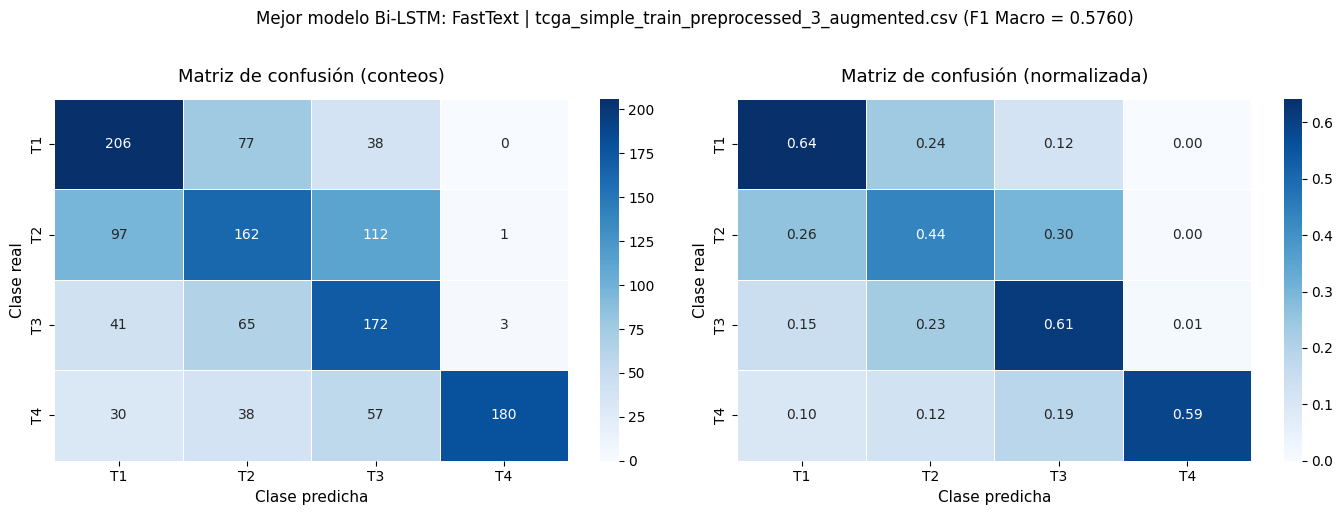

Figura guardada en ../Results/Figures/bi_lstm_confusion_matrix.png


In [13]:
# Matriz de confusión del mejor modelo Bi-LSTM

if best_predictions is None or best_true_labels is None or best_label_encoder is None:
    raise ValueError(
        "No hay predicciones guardadas. Ejecuta primero la celda de entrenamiento/evaluación."
    )

os.makedirs('../Results/Figures', exist_ok=True)

cm = confusion_matrix(best_true_labels, best_predictions)

# Normalizamos por fila para ver proporciones. Es más útil si las clases están desbalanceadas.
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(
    cm.astype(float),
    row_sums,
    out=np.zeros_like(cm, dtype=float),
    where=row_sums != 0
)

class_names = [str(c) for c in best_label_encoder.classes_]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Matriz de confusión (conteos)', 'Matriz de confusión (normalizada)']
):
    sns.heatmap(
        data,
        annot=True,
        fmt=fmt,
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel('Clase predicha', fontsize=11)
    ax.set_ylabel('Clase real', fontsize=11)

fig.suptitle(
    f"Mejor modelo Bi-LSTM: {best_model_info['Vectorizacion']} | {best_model_info['Dataset']} "
    f"(F1 Macro = {best_f1:.4f})",
    fontsize=12,
    y=1.02
)

plt.tight_layout()
plt.savefig('../Results/Figures/bi_lstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figura guardada en ../Results/Figures/bi_lstm_confusion_matrix.png")

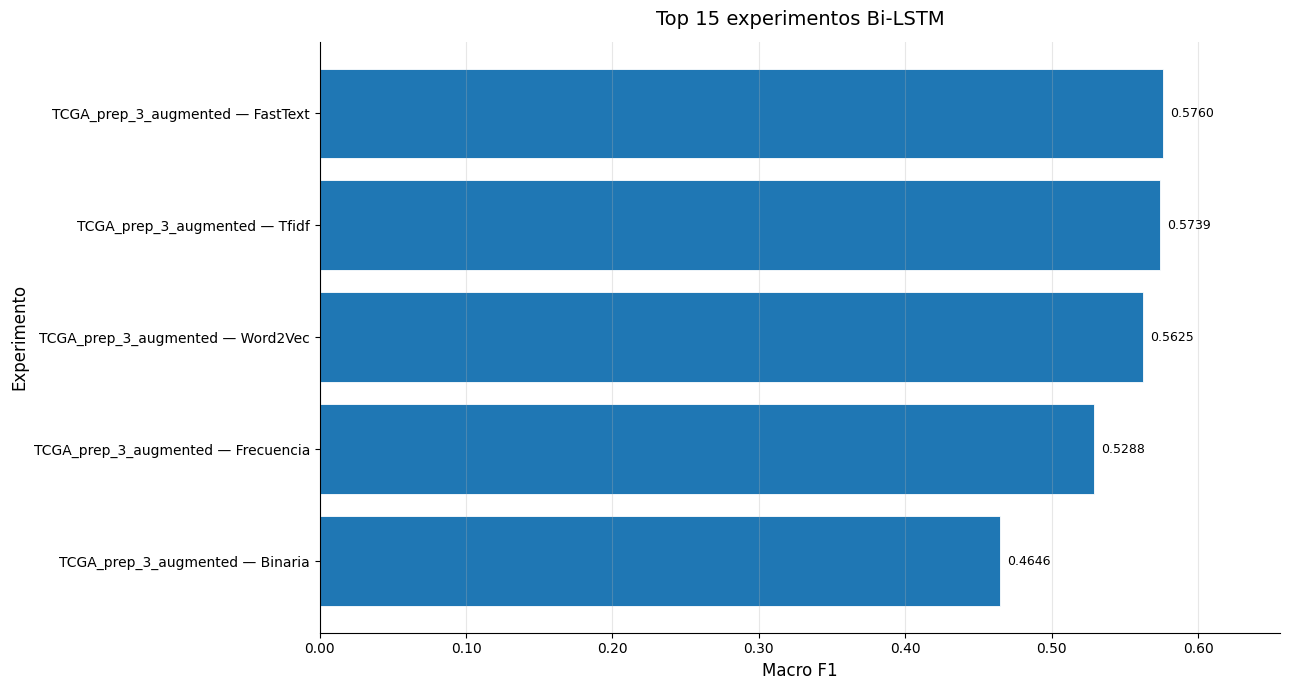

Figura guardada en ../Results/Figures/bi_lstm_top15_experimentos.png


In [15]:
# Comparativa Bi-LSTM: Top 15 experimentos por F1 Macro

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

if 'df_resultados' not in globals() or df_resultados.empty:
    raise ValueError(
        "df_resultados no existe o está vacío. Ejecuta primero la celda de entrenamiento/evaluación."
    )

os.makedirs('../Results/Figures', exist_ok=True)

df_plot = df_resultados.copy()

# Nos aseguramos de que Macro_F1 es numérico
df_plot['Macro_F1'] = pd.to_numeric(df_plot['Macro_F1'], errors='coerce')
df_plot = df_plot.dropna(subset=['Macro_F1'])

# Creamos una etiqueta corta para cada experimento
df_plot['Dataset_corto'] = (
    df_plot['Dataset']
    .astype(str)
    .str.replace('tcga_simple_train', 'TCGA', regex=False)
    .str.replace('_preprocessed_', '_prep_', regex=False)
    .str.replace('.csv', '', regex=False)
)

df_plot['Experimento'] = (
    df_plot['Dataset_corto'].astype(str)
    + ' — '
    + df_plot['Vectorizacion'].astype(str)
)

# Ordenamos y nos quedamos con los 15 mejores
top_n = 15
df_top = (
    df_plot
    .sort_values('Macro_F1', ascending=False)
    .head(top_n)
    .sort_values('Macro_F1', ascending=True)  # Para que el mejor quede arriba en barh
)

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    df_top['Experimento'],
    df_top['Macro_F1'],
    edgecolor='white',
    linewidth=0.6
)

# Etiquetas al final de cada barra
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.4f}',
        va='center',
        ha='left',
        fontsize=9
    )

ax.set_xlabel('Macro F1', fontsize=12)
ax.set_ylabel('Experimento', fontsize=12)
ax.set_title(f'Top {top_n} experimentos Bi-LSTM', fontsize=14, pad=12)

ax.set_xlim(0, min(1.0, df_top['Macro_F1'].max() + 0.08))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

ax.grid(axis='x', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('../Results/Figures/bi_lstm_top15_experimentos.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figura guardada en ../Results/Figures/bi_lstm_top15_experimentos.png")